In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve


def resolve_data_path(filename='Data_oil.xlsx'):
    candidates = [
        filename,
        os.path.join(os.getcwd(), filename),
        os.path.join('/mnt/data', filename),
        os.path.join('/content', filename),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    return None


file_path = resolve_data_path('Data_oil.xlsx')

dt_data = 1.0 / 252.0
mu = 0.03
kappa = 1.0
theta = 0.0
sigma_P = 0.2
sigma_X = 0.1
sigma_delta = sigma_X
rho_12 = 0.0
mean_sigma = 0.30
vol_of_vol = 0.10
kappa_y = 1.0
theta_y = mean_sigma**2
sigma_y = 2.0 * vol_of_vol * mean_sigma
x0_data = 0.0
y0_data = theta_y
P0_data = 50.0
df = None


def positive_log_ratio(a, b):
    ratio = pd.Series(np.nan, index=a.index, dtype=float)
    mask = (a > 0) & (b > 0)
    ratio.loc[mask] = np.log(a.loc[mask] / b.loc[mask])
    return ratio

def estimate_cir_params_from_y(y_series, dt=1/252, eps=1e-8):
    y = pd.Series(y_series).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    y = y[y > eps]

    if len(y) < 10:
        return None

    y_n = y.iloc[:-1].to_numpy()
    y_np1 = y.iloc[1:].to_numpy()
    dy = y_np1 - y_n

    X = np.column_stack([np.ones_like(y_n), y_n])

    weights = 1.0 / np.maximum(y_n, eps)
    model = sm.WLS(dy, X, weights=weights).fit()

    alpha_hat, beta_hat = model.params

    kappa_y_hat = max(-beta_hat / dt, eps)
    theta_y_hat = max(-alpha_hat / beta_hat, eps) if abs(beta_hat) > eps else np.nan

    resid = dy - (alpha_hat + beta_hat * y_n)
    sigma_y_hat = np.std(resid / np.sqrt(np.maximum(y_n, eps) * dt), ddof=1)

    return {
        "kappa_y": float(kappa_y_hat),
        "theta_y": float(max(theta_y_hat, eps)),
        "sigma_y": float(max(sigma_y_hat, eps)),
        "summary": model.summary()
    }

if file_path is not None:
    try:
        df_futures = pd.read_excel(file_path, sheet_name='OIL FUTURES CURVES', skiprows=1)
        df_rates = pd.read_excel(file_path, sheet_name='INTEREST RATE', skiprows=1)
        df_ovx = pd.read_excel(file_path, sheet_name='OVX INDEX', skiprows=1)

        for df_temp in [df_futures, df_rates, df_ovx]:
            df_temp.drop(columns=[col for col in df_temp.columns if 'Unnamed' in col], inplace=True, errors='ignore')
            df_temp['DATES'] = pd.to_datetime(df_temp['DATES'], errors='coerce')
            df_temp.dropna(subset=['DATES'], inplace=True)
            df_temp.set_index('DATES', inplace=True)

        df = df_futures.join(df_rates, how='inner').join(df_ovx, how='inner')
        df = df.dropna(subset=['CL1 COMDTY', 'CL7 COMDTY', 'SOFRRATE INDEX', 'OVX INDEX'])

        P_t = df['CL1 COMDTY'].astype(float)
        F_t_T = df['CL7 COMDTY'].astype(float)
        tau = 6.0 / 12.0
        r_t = df['SOFRRATE INDEX'].astype(float) / 100.0

        delta_t = r_t - (1.0 / tau) * positive_log_ratio(F_t_T, P_t)
        delta_t = delta_t.replace([np.inf, -np.inf], np.nan)

        log_ret = positive_log_ratio(P_t, P_t.shift(1)).dropna()
        delta_t_shifted = delta_t.shift(1).dropna()
        common_idx = log_ret.index.intersection(delta_t_shifted.index)
        log_ret = log_ret.loc[common_idx]
        delta_t_shifted = delta_t_shifted.loc[common_idx]

        if len(log_ret) > 5:
            sigma_P = float(log_ret.std() / np.sqrt(dt_data))
            mu = float((log_ret.mean() / dt_data) + delta_t_shifted.mean() + 0.5 * sigma_P**2)

        x_series = (mu - delta_t).replace([np.inf, -np.inf], np.nan).dropna()

        X = x_series.shift(1).dropna()
        Y = x_series.dropna()
        common_idx2 = X.index.intersection(Y.index)
        X = X.loc[common_idx2]
        Y = Y.loc[common_idx2]

        x_innov = None
        if len(X) > 5:
            X_sm = sm.add_constant(X)
            model = sm.OLS(Y, X_sm).fit()
            a_hat, b_hat = model.params.values
            kappa = float(max((1.0 - b_hat) / dt_data, 1e-8))
            x_bar = float(a_hat / max(1.0 - b_hat, 1e-8))
            theta = float(mu - x_bar)
            sigma_X = float(model.resid.std() / np.sqrt(dt_data))
            sigma_delta = sigma_X
            x_innov = Y - model.predict(X_sm)

        x0_candidates = x_series.dropna()
        if len(x0_candidates) > 0:
            x0_data = float(x0_candidates.iloc[0])

        if x_innov is not None:
            common_idx3 = log_ret.index.intersection(x_innov.index)
            if len(common_idx3) > 5:
                ret_centered = log_ret.loc[common_idx3] - log_ret.loc[common_idx3].mean()
                rho_12 = float(np.corrcoef(ret_centered, x_innov.loc[common_idx3])[0, 1])
                if not np.isfinite(rho_12):
                    rho_12 = 0.0
                rho_12 = float(np.clip(rho_12, -0.95, 0.95))

        sigma_t = (df['OVX INDEX'].astype(float) / 100.0).replace([np.inf, -np.inf], np.nan).dropna()
        sigma_t = sigma_t[sigma_t > 0]

        if len(sigma_t) > 5:
            mean_sigma = float(sigma_t.mean())
            vol_of_vol = float(positive_log_ratio(sigma_t, sigma_t.shift(1)).dropna().std() / np.sqrt(dt_data))

            y_series = sigma_t**2
            cir_est = estimate_cir_params_from_y(y_series, dt=dt_data)

            if cir_est is not None:
                kappa_y = cir_est["kappa_y"]
                theta_y = cir_est["theta_y"]
                sigma_y = cir_est["sigma_y"]
            else:
                kappa_y = 1.0
                theta_y = float(max(mean_sigma**2, 1e-8))
                sigma_y = float(max(2.0 * vol_of_vol * max(mean_sigma, 1e-8), 1e-8))
        else:
            kappa_y = 1.0
            theta_y = float(max(mean_sigma**2, 1e-8))
            sigma_y = float(max(2.0 * vol_of_vol * max(mean_sigma, 1e-8), 1e-8))

        P0_candidates = P_t[P_t > 0]
        if len(P0_candidates) > 0:
            P0_data = float(P0_candidates.iloc[0])
        x0_candidates = x_series.dropna()
        if len(x0_candidates) > 0:
            x0_data = float(x0_candidates.iloc[0])
        y0_candidates = sigma_t**2
        if len(y0_candidates) > 0:
            y0_data = float(y0_candidates.iloc[0])

        print(f"Calibration loaded from Excel: {file_path}")
    except Exception as exc:
        print(f"Calibration file found but could not be read cleanly: {exc}")
        print("Using fallback defaults instead.")
else:
    print("Calibration file not found. Using fallback defaults.")

print(f"mu = {mu:.4f}")
print(f"kappa = {kappa:.4f}")
print(f"theta = {theta:.4f}")
print(f"sigma_P = {sigma_P:.4f}")
print(f"sigma_delta = {sigma_delta:.4f}")
print(f"rho_12 = {rho_12:.4f}")
print(f"mean_sigma = {mean_sigma:.4f}")
print(f"vol_of_vol = {vol_of_vol:.4f}")
print(f"kappa_y = {kappa_y:.4f}")
print(f"theta_y = {theta_y:.4f}")
print(f"sigma_y = {sigma_y:.4f}")
print(f"P0_data = {P0_data:.4f}, x0_data = {x0_data:.4f}, y0_data = {y0_data:.4f}")


Calibration loaded from Excel: Data_oil.xlsx
mu = 0.3803
kappa = 5.4546
theta = 0.0876
sigma_P = 0.4979
sigma_delta = 0.5878
rho_12 = -0.7542
mean_sigma = 0.4278
vol_of_vol = 1.1092
kappa_y = 3.7114
theta_y = 0.2452
sigma_y = 2.3978
P0_data = 46.5400, x0_data = 0.4456, y0_data = 0.2994


In [46]:


def central_derivative_matrix(n, h):
    D = sp.lil_matrix((n, n), dtype=float)
    if n <= 1:
        return D.tocsr()
    for i in range(1, n - 1):
        D[i, i - 1] = -0.5 / h
        D[i, i + 1] = 0.5 / h
    return D.tocsr()


def forward_derivative_matrix(n, h):
    D = sp.lil_matrix((n, n), dtype=float)
    if n <= 1:
        return D.tocsr()
    for i in range(0, n - 1):
        D[i, i] = -1.0 / h
        D[i, i + 1] = 1.0 / h
    return D.tocsr()


def backward_derivative_matrix(n, h):
    D = sp.lil_matrix((n, n), dtype=float)
    if n <= 1:
        return D.tocsr()
    for i in range(1, n):
        D[i, i - 1] = -1.0 / h
        D[i, i] = 1.0 / h
    return D.tocsr()


def second_derivative_matrix_neumann(n, h):
    D2 = sp.lil_matrix((n, n), dtype=float)
    if n <= 1:
        return D2.tocsr()
    if n == 2:
        D2[0, 0] = -2.0 / (h * h)
        D2[0, 1] = 2.0 / (h * h)
        D2[1, 0] = 2.0 / (h * h)
        D2[1, 1] = -2.0 / (h * h)
        return D2.tocsr()

    for i in range(1, n - 1):
        D2[i, i - 1] = 1.0 / (h * h)
        D2[i, i] = -2.0 / (h * h)
        D2[i, i + 1] = 1.0 / (h * h)

    D2[0, 0] = -2.0 / (h * h)
    D2[0, 1] = 2.0 / (h * h)
    D2[-1, -2] = 2.0 / (h * h)
    D2[-1, -1] = -2.0 / (h * h)
    return D2.tocsr()


def nearest_index(grid, value):
    value = np.clip(value, grid[0], grid[-1])
    return int(np.abs(grid - value).argmin())


def make_grids(NP=12, Nx=12, Ny=8, Nz=1):
    if df is not None and 'CL1 COMDTY' in df.columns:
        P_positive = df['CL1 COMDTY'][df['CL1 COMDTY'] > 0]
        if len(P_positive) > 10:
            P_lo = float(max(1e-2, 0.8 * P_positive.quantile(0.01)))
            P_hi = float(1.2 * P_positive.quantile(0.99))
        else:
            P_lo, P_hi = 1e-2, 100.0
    else:
        P_lo, P_hi = 1e-2, 100.0
    P_hi = max(P_hi, P_lo + 10.0)

    station_std_x = sigma_delta / np.sqrt(max(2.0 * kappa, 1e-8))
    x_long_run = mu - theta
    x_lo = min(x_long_run - 4.0 * station_std_x, -0.5)
    x_hi = max(x_long_run + 4.0 * station_std_x, 0.5)

    y_hi = max(1.0, 4.0 * theta_y, 2.0 * y0_data)
    P_grid = np.linspace(P_lo, P_hi, NP)
    x_grid = np.linspace(x_lo, x_hi, Nx)
    y_grid = np.linspace(1e-6, y_hi, Ny)
    z_grid = np.array([0.0]) if Nz == 1 else np.linspace(1e-6, 1.0, Nz)
    P_mesh, x_mesh, y_mesh, z_mesh = np.meshgrid(P_grid, x_grid, y_grid, z_grid, indexing='ij')
    return P_grid, x_grid, y_grid, z_grid, P_mesh, x_mesh, y_mesh, z_mesh


def kron4(A, B, C, D):
    return sp.kron(A, sp.kron(B, sp.kron(C, D, format='csr'), format='csr'), format='csr')


def build_generator_matrix(P_grid, x_grid, y_grid, z_grid, params, is_sv_model=True):
    """
    Reduced one-factor stochastic-volatility generator on (P, x, y).

    Important note on upwinding:
    the HJB is solved from terminal time backward, equivalently forward in
    tau = T - t. The monotone upwind direction must therefore be chosen for
    the forward-in-tau transport speed, which reverses the naive stencil
    selection that caused the previous notebook to blow up.
    """
    NP, Nx, Ny, Nz = len(P_grid), len(x_grid), len(y_grid), len(z_grid)
    dP = float(P_grid[1] - P_grid[0]) if NP > 1 else 1.0
    dx = float(x_grid[1] - x_grid[0]) if Nx > 1 else 1.0
    dy = float(y_grid[1] - y_grid[0]) if Ny > 1 else 1.0
    dz = float(z_grid[1] - z_grid[0]) if Nz > 1 else 1.0

    Dp_c = central_derivative_matrix(NP, dP)
    Dp_f = forward_derivative_matrix(NP, dP)
    Dp_b = backward_derivative_matrix(NP, dP)
    Dpp = second_derivative_matrix_neumann(NP, dP)

    Dx_c = central_derivative_matrix(Nx, dx)
    Dx_f = forward_derivative_matrix(Nx, dx)
    Dx_b = backward_derivative_matrix(Nx, dx)
    Dxx = second_derivative_matrix_neumann(Nx, dx)

    Dy_c = central_derivative_matrix(Ny, dy)
    Dy_f = forward_derivative_matrix(Ny, dy)
    Dy_b = backward_derivative_matrix(Ny, dy)
    Dyy = second_derivative_matrix_neumann(Ny, dy)

    Dz_c = central_derivative_matrix(Nz, dz)
    Dzz = second_derivative_matrix_neumann(Nz, dz)

    I_P = sp.eye(NP, format='csr')
    I_x = sp.eye(Nx, format='csr')
    I_y = sp.eye(Ny, format='csr')
    I_z = sp.eye(Nz, format='csr')

    DP_c = kron4(I_z, I_y, I_x, Dp_c)
    DP_f = kron4(I_z, I_y, I_x, Dp_f)
    DP_b = kron4(I_z, I_y, I_x, Dp_b)
    DPP = kron4(I_z, I_y, I_x, Dpp)

    DX_c = kron4(I_z, I_y, Dx_c, I_P)
    DX_f = kron4(I_z, I_y, Dx_f, I_P)
    DX_b = kron4(I_z, I_y, Dx_b, I_P)
    DXX = kron4(I_z, I_y, Dxx, I_P)

    DY_c = kron4(I_z, Dy_c, I_x, I_P)
    DY_f = kron4(I_z, Dy_f, I_x, I_P)
    DY_b = kron4(I_z, Dy_b, I_x, I_P)
    DYY = kron4(I_z, Dyy, I_x, I_P)

    DZ_c = kron4(Dz_c, I_y, I_x, I_P)
    DZZ = kron4(Dzz, I_y, I_x, I_P)

    P_mesh, x_mesh, y_mesh, z_mesh = np.meshgrid(P_grid, x_grid, y_grid, z_grid, indexing='ij')

    if is_sv_model:
        sig = np.sqrt(np.maximum(y_mesh, 1e-12))
    else:
        sig = np.sqrt(np.maximum(params['theta_y'], 1e-12)) * np.ones_like(y_mesh)

    coeff_P = (P_mesh * x_mesh).ravel(order='F')
    coeff_PP = (0.5 * sig**2 * P_mesh**2).ravel(order='F')
    coeff_x = (params['kappa'] * (params['mu'] - params['theta'] - x_mesh)).ravel(order='F')
    coeff_xx = np.full(P_mesh.size, 0.5 * params['sigma_delta']**2, dtype=float)
    coeff_Px = (params['rho_12'] * sig * params['sigma_delta'] * P_mesh).ravel(order='F')
    coeff_y = (params['kappa_y'] * (params['theta_y'] - y_mesh)).ravel(order='F')
    coeff_yy = (0.5 * (params['sigma_y']**2) * np.maximum(y_mesh, 0.0)).ravel(order='F')

    pos_P, neg_P = np.maximum(coeff_P, 0.0), np.minimum(coeff_P, 0.0)
    pos_x, neg_x = np.maximum(coeff_x, 0.0), np.minimum(coeff_x, 0.0)
    pos_y, neg_y = np.maximum(coeff_y, 0.0), np.minimum(coeff_y, 0.0)

    L = (
        sp.diags(pos_P, 0, format='csr') @ DP_f
        + sp.diags(neg_P, 0, format='csr') @ DP_b
        + sp.diags(coeff_PP, 0, format='csr') @ DPP
        + sp.diags(pos_x, 0, format='csr') @ DX_f
        + sp.diags(neg_x, 0, format='csr') @ DX_b
        + sp.diags(coeff_xx, 0, format='csr') @ DXX
        + sp.diags(coeff_Px, 0, format='csr') @ (DX_c @ DP_c)
        + sp.diags(pos_y, 0, format='csr') @ DY_f
        + sp.diags(neg_y, 0, format='csr') @ DY_b
        + sp.diags(coeff_yy, 0, format='csr') @ DYY
    )

    if Nz > 1:
        L = L + 0.0 * DZ_c + 0.0 * DZZ

    return L.tocsr(), {
        'dP': dP, 'dx': dx, 'dy': dy, 'dz': dz,
        'P_mesh': P_mesh, 'x_mesh': x_mesh, 'y_mesh': y_mesh, 'z_mesh': z_mesh,
        'sig_grid': sig,
    }


In [47]:


def run_backward_pde(
    gamma_val,
    is_sv_model=True,
    verbose=False,
    NP=12,
    Nx=12,
    Ny=8,
    Nz=1,
    T=1.0,
    dt_solver=1.0 / 252.0,
    max_picard_iters=25,
    picard_tol=1e-8,
    enforce_concavity=True,
):
    if verbose:
        mode = "Stochastic Volatility" if is_sv_model else "Constant Volatility Baseline"
        print(f"--- Starting PDE Solver [{mode}] (gamma = {gamma_val:.3f}) ---")

    P_grid, x_grid, y_grid, z_grid, P_mesh, x_mesh, y_mesh, z_mesh = make_grids(NP, Nx, Ny, Nz)

    params = dict(
        kappa=float(kappa),
        mu=float(mu),
        theta=float(theta),
        sigma_delta=float(sigma_delta),
        rho_12=float(rho_12),
        kappa_y=float(kappa_y),
        theta_y=float(theta_y),
        sigma_y=float(sigma_y),
        K=0.5,
        rho=0.05,
        alpha_terminal=2.0,
    )

    L, grid_info = build_generator_matrix(P_grid, x_grid, y_grid, z_grid, params, is_sv_model=is_sv_model)
    params.update(grid_info)
    params['L'] = L
    params['T'] = float(T)

    K = params['K']
    rho = params['rho']
    shape = (NP, Nx, Ny, Nz)
    n_nodes = NP * Nx * Ny * Nz

    alpha_terminal = float(params['alpha_terminal'])

    a = -0.5 * alpha_terminal * np.ones(shape, dtype=float)
    b = np.zeros(shape, dtype=float)
    c = np.zeros(shape, dtype=float)

    a_history = [a.copy()]
    b_history = [b.copy()]
    c_history = [c.copy()]

    n_steps = max(int(round(T / dt_solver)), 1)
    dt_solver = T / n_steps

    I = sp.eye(n_nodes, format='csr')
    sig_grid = params['sig_grid']

    P_flat = P_mesh.ravel(order='F')
    x_flat = x_mesh.ravel(order='F')
    source_a = 0.5 * gamma_val * (sig_grid.ravel(order='F') ** 2) * (P_flat ** 2)
    source_b = P_flat * x_flat

    for step in range(n_steps):
        a_old = a.ravel(order='F')
        b_old = b.ravel(order='F')
        c_old = c.ravel(order='F')

        a_guess = a_old.copy()
        rhs_a = a_old - dt_solver * source_a

        for _k in range(max_picard_iters):
            A_a = (
                I
                - dt_solver * L
                + dt_solver * rho * I
                - dt_solver * sp.diags((2.0 / K) * a_guess, 0, format='csr')
            )
            a_new = spsolve(A_a, rhs_a)
            if np.linalg.norm(a_new - a_guess, ord=np.inf) < picard_tol:
                a_guess = a_new
                break
            a_guess = a_new
        a_new = a_guess

        rhs_b = b_old + dt_solver * source_b
        A_b = I - dt_solver * L + dt_solver * rho * I - dt_solver * sp.diags((2.0 / K) * a_new, 0, format='csr')
        b_new = spsolve(A_b, rhs_b)

        rhs_c = c_old + dt_solver * (0.5 / K) * (b_new ** 2)
        A_c = I - dt_solver * L + dt_solver * rho * I
        c_new = spsolve(A_c, rhs_c)

        a = np.nan_to_num(a_new.reshape(shape, order='F'), nan=0.0, posinf=0.0, neginf=0.0)
        if enforce_concavity:
            a = np.minimum(a, 0.0)
        b = np.nan_to_num(b_new.reshape(shape, order='F'), nan=0.0, posinf=0.0, neginf=0.0)
        c = np.nan_to_num(c_new.reshape(shape, order='F'), nan=0.0, posinf=0.0, neginf=0.0)

        a_history.append(a.copy())
        b_history.append(b.copy())
        c_history.append(c.copy())

        if verbose and ((step + 1) % max(1, n_steps // 5) == 0 or step == n_steps - 1):
            print(
                f"Step {step + 1:4d}/{n_steps}: "
                f"a in [{a.min(): .4e}, {a.max(): .4e}], "
                f"b in [{b.min(): .4e}, {b.max(): .4e}]"
            )

    if verbose:
        print("--- Backward induction complete ---\n")

    a_history = a_history[::-1]
    b_history = b_history[::-1]
    c_history = c_history[::-1]

    return a_history, b_history, c_history, P_grid, x_grid, y_grid, z_grid, dt_solver, params


def simulate_forward_path(
    a_hist,
    b_hist,
    gamma_val,
    params,
    P_grid,
    x_grid,
    y_grid,
    z_grid,
    dt_solver,
    is_sv_model=True,
    seed=None,
    df=None,
):
    rng = np.random.default_rng(seed)

    K = params['K']
    kappa = params['kappa']
    mu = params['mu']
    theta = params['theta']
    sigma_delta = params['sigma_delta']
    rho_12 = params['rho_12']
    kappa_y = params['kappa_y']
    theta_y = params['theta_y']
    sigma_y = params['sigma_y']
    alpha_terminal = float(params.get('alpha_terminal', 0.0))

    time_steps = len(a_hist)

    P_t = float(P0_data)
    x_t = float(np.clip(x0_data, x_grid[0], x_grid[-1]))
    y_t = float(np.clip(max(y0_data, 1e-8), y_grid[0], y_grid[-1]))
    z_t = 0.0
    Q_t = 0.0
    cash_t = 0.0

    Q_path = np.zeros(time_steps)
    X_path = np.zeros(time_steps)
    PnL_path = np.zeros(time_steps)
    P_path = np.zeros(time_steps)

    for n in range(time_steps - 1):
        a_n = a_hist[n]
        b_n = b_hist[n]

        idx_P = nearest_index(P_grid, P_t)
        idx_x = nearest_index(x_grid, x_t)
        idx_y = nearest_index(y_grid, y_t)
        idx_z = nearest_index(z_grid, z_t)

        a_val = float(a_n[idx_P, idx_x, idx_y, idx_z])
        b_val = float(b_n[idx_P, idx_x, idx_y, idx_z])
        u_star = (2.0 * a_val * Q_t + b_val) / K

        dW_P = rng.normal(0.0, np.sqrt(dt_solver))
        dW_x_ind = rng.normal(0.0, np.sqrt(dt_solver))
        dW_x = rho_12 * dW_P + np.sqrt(max(1.0 - rho_12 ** 2, 0.0)) * dW_x_ind
        dW_y = rng.normal(0.0, np.sqrt(dt_solver))

        current_vol = np.sqrt(max(y_t, 1e-12)) if is_sv_model else np.sqrt(max(theta_y, 1e-12))
        P_next = P_t + P_t * x_t * dt_solver + current_vol * P_t * dW_P
        x_next = x_t + kappa * (mu - theta - x_t) * dt_solver + sigma_delta * dW_x
        y_next = max(y_t + kappa_y * (theta_y - y_t) * dt_solver + sigma_y * np.sqrt(max(y_t, 0.0)) * dW_y, 0.0)

        Q_next = Q_t + u_star * dt_solver
        cash_next = cash_t - u_star * P_t * dt_solver - 0.5 * K * (u_star ** 2) * dt_solver

        P_path[n] = P_t
        Q_path[n] = Q_t
        X_path[n] = x_t
        PnL_path[n] = cash_t + Q_t * P_t

        P_t, x_t, y_t, Q_t, cash_t = P_next, x_next, y_next, Q_next, cash_next

    P_path[-1] = P_t
    Q_path[-1] = Q_t
    X_path[-1] = x_t
    PnL_path[-1] = cash_t + Q_t * P_t - 0.5 * alpha_terminal * (Q_t ** 2)

    return Q_path, X_path, PnL_path, P_path


Solving backward PDEs for gamma = 0.5 ...
--- Starting PDE Solver [Stochastic Volatility] (gamma = 0.500) ---
Step   50/252: a in [-3.1567e+01, -9.4601e-01], b in [-2.2098e+00,  6.1482e+00]
Step  100/252: a in [-3.1567e+01, -9.8928e-01], b in [-2.1839e+00,  6.1547e+00]
Step  150/252: a in [-3.1567e+01, -9.9609e-01], b in [-2.1833e+00,  6.1548e+00]
Step  200/252: a in [-3.1567e+01, -9.9703e-01], b in [-2.1833e+00,  6.1548e+00]
Step  250/252: a in [-3.1567e+01, -9.9715e-01], b in [-2.1833e+00,  6.1548e+00]
Step  252/252: a in [-3.1567e+01, -9.9715e-01], b in [-2.1833e+00,  6.1548e+00]
--- Backward induction complete ---



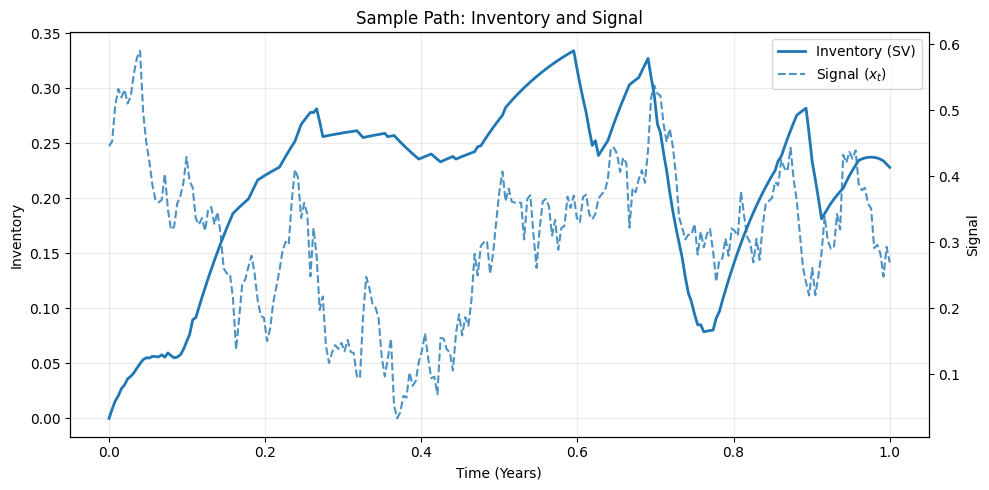

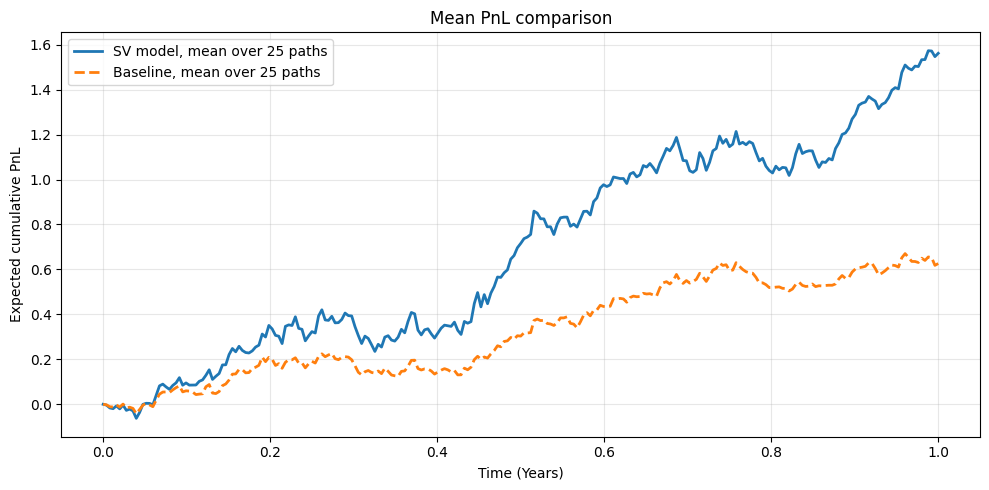

Final mean PnL (SV)      : 1.5616
Final mean PnL (baseline): 0.6261
Outperformance           : 0.9355


In [53]:
gamma_test = 0.5
num_paths = 25

print(f"Solving backward PDEs for gamma = {gamma_test} ...")
a_hist_sv, b_hist_sv, c_hist_sv, P_grid, x_grid, y_grid, z_grid, dt_solver, params = run_backward_pde(
    gamma_val=gamma_test,
    is_sv_model=True,
    verbose=True,
    NP=12,
    Nx=12,
    Ny=8,
    Nz=1,
    T=1.0,
    dt_solver=1.0 / 252.0,
)

a_hist_base, b_hist_base, c_hist_base, *_ = run_backward_pde(
    gamma_val=gamma_test,
    is_sv_model=False,
    verbose=False,
    NP=12,
    Nx=12,
    Ny=8,
    Nz=1,
    T=1.0,
    dt_solver=1.0 / 252.0,
)

time_steps = len(a_hist_sv)
time_axis = np.linspace(0.0, (time_steps - 1) * dt_solver, time_steps)

all_pnl_sv = np.zeros((num_paths, time_steps))
all_pnl_base = np.zeros((num_paths, time_steps))
sample_Q_sv = None
sample_X_sv = None

for i in range(num_paths):
    Q_sv, X_sv, PnL_sv, _ = simulate_forward_path(
        a_hist_sv, b_hist_sv, gamma_test, params,
        P_grid, x_grid, y_grid, z_grid, dt_solver,
        is_sv_model=True, seed=i, df=df,
    )
    Q_base, X_base, PnL_base, _ = simulate_forward_path(
        a_hist_base, b_hist_base, gamma_test, params,
        P_grid, x_grid, y_grid, z_grid, dt_solver,
        is_sv_model=False, seed=i, df=df,
    )

    all_pnl_sv[i, :] = PnL_sv
    all_pnl_base[i, :] = PnL_base

    if i == 1:
        sample_Q_sv = Q_sv
        sample_X_sv = X_sv

mean_pnl_sv = all_pnl_sv.mean(axis=0)
mean_pnl_base = all_pnl_base.mean(axis=0)

fig, ax1 = plt.subplots(figsize=(10, 5))

line1 = ax1.plot(time_axis, sample_Q_sv, linewidth=2, label='Inventory (SV)')
ax1.set_xlabel('Time (Years)')
ax1.set_ylabel('Inventory')
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
line2 = ax2.plot(time_axis, sample_X_sv, linestyle='--', alpha=0.8, label='Signal ($x_t$)')
ax2.set_ylabel('Signal')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('Sample Path: Inventory and Signal')
fig.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(time_axis, mean_pnl_sv, linewidth=2, label=f'SV model, mean over {num_paths} paths')
plt.plot(time_axis, mean_pnl_base, linestyle='--', linewidth=2, label=f'Baseline, mean over {num_paths} paths')
plt.xlabel('Time (Years)')
plt.ylabel('Expected cumulative PnL')
plt.title('Mean PnL comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final mean PnL (SV)      : {mean_pnl_sv[-1]:.4f}")
print(f"Final mean PnL (baseline): {mean_pnl_base[-1]:.4f}")
print(f"Outperformance           : {(mean_pnl_sv[-1] - mean_pnl_base[-1]):.4f}")


Solving backward PDEs for gamma = 0.5 ...
--- Starting PDE Solver [Stochastic Volatility] (gamma = 0.500) ---
Step   50/252: a in [-3.1567e+01, -9.4601e-01], b in [-2.2098e+00,  6.1482e+00]
Step  100/252: a in [-3.1567e+01, -9.8928e-01], b in [-2.1839e+00,  6.1547e+00]
Step  150/252: a in [-3.1567e+01, -9.9609e-01], b in [-2.1833e+00,  6.1548e+00]
Step  200/252: a in [-3.1567e+01, -9.9703e-01], b in [-2.1833e+00,  6.1548e+00]
Step  250/252: a in [-3.1567e+01, -9.9715e-01], b in [-2.1833e+00,  6.1548e+00]
Step  252/252: a in [-3.1567e+01, -9.9715e-01], b in [-2.1833e+00,  6.1548e+00]
--- Backward induction complete ---



,strategy,mean_terminal_pnl,median_terminal_pnl,std_terminal_pnl,p05_terminal_pnl,p95_terminal_pnl,prob_positive_terminal_pnl,ci95_low_mean_pnl,ci95_high_mean_pnl,mean_terminal_inventory,mean_abs_inventory,mean_turnover,mean_max_drawdown
0,SV,2.0403,1.8460,2.2956,-1.3843,6.0003,0.8320,1.9767,2.1040,0.1122,0.1454,1.1326,1.8726
1,Baseline,0.8517,0.9436,1.0831,-1.0919,2.4645,0.7986,0.8217,0.8818,0.0410,0.0510,0.3093,1.1390
2,SV - Baseline,1.1886,0.8815,1.8115,-1.1860,4.6001,0.7284,1.1384,1.2388,0.0712,0.0943,0.8233,0.7336


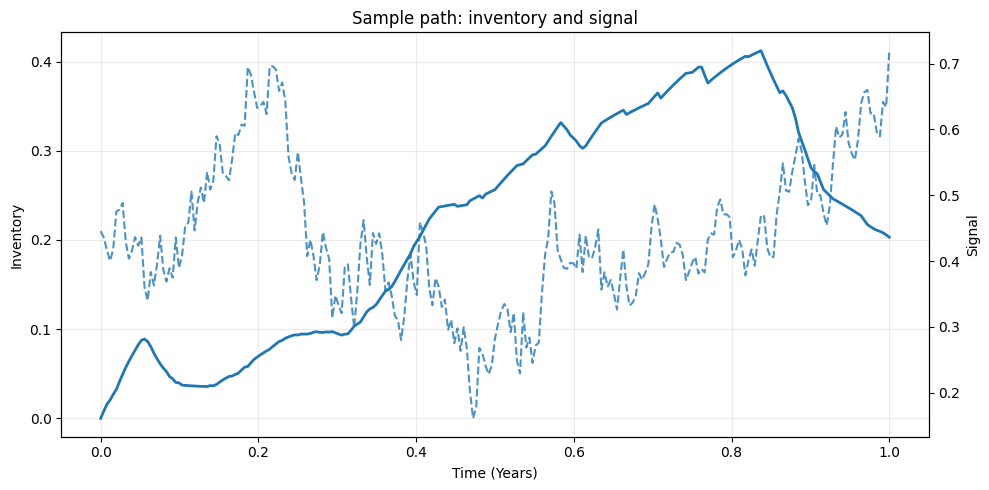

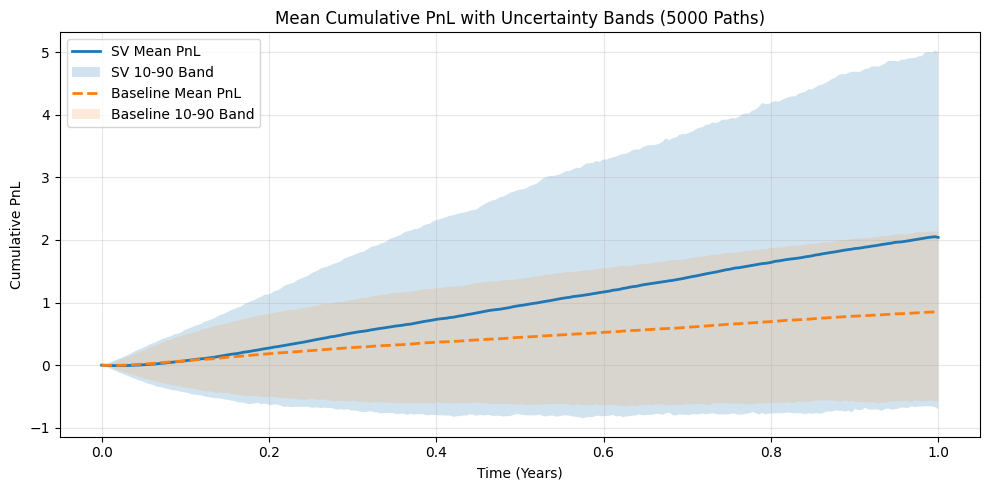

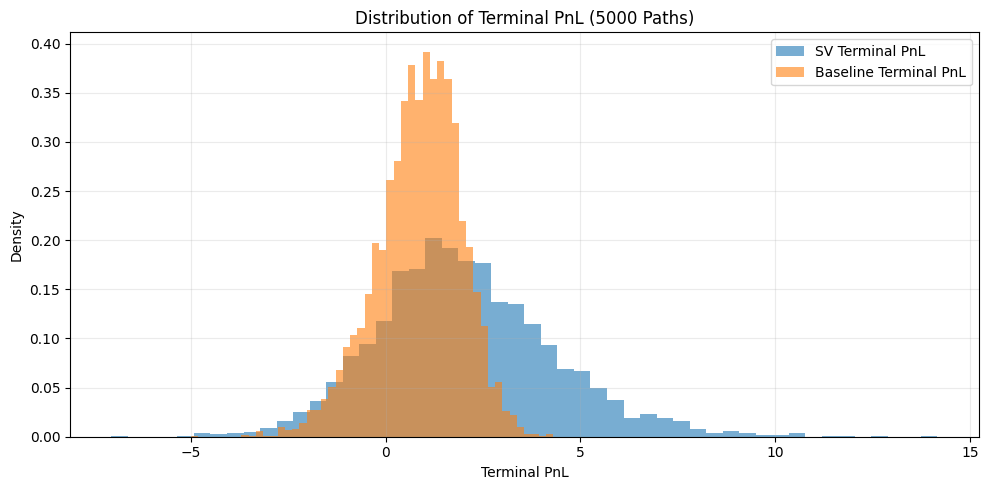

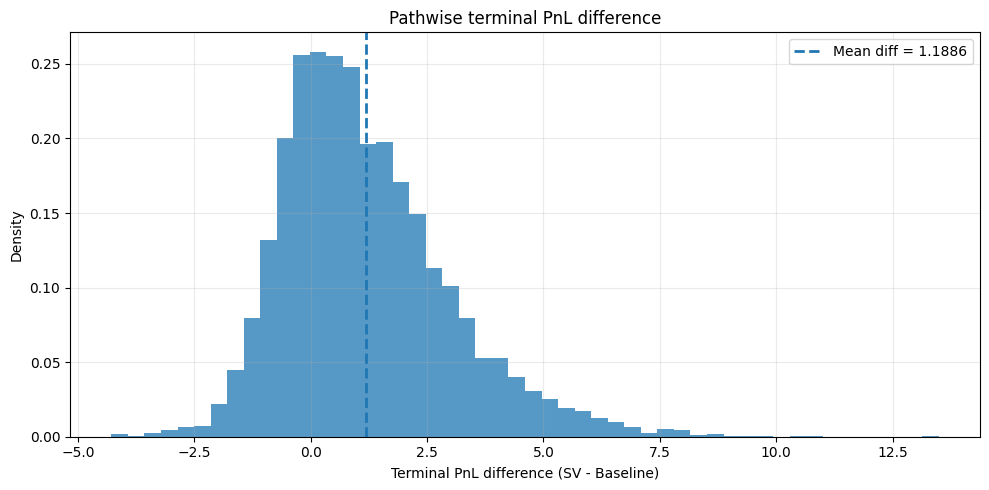

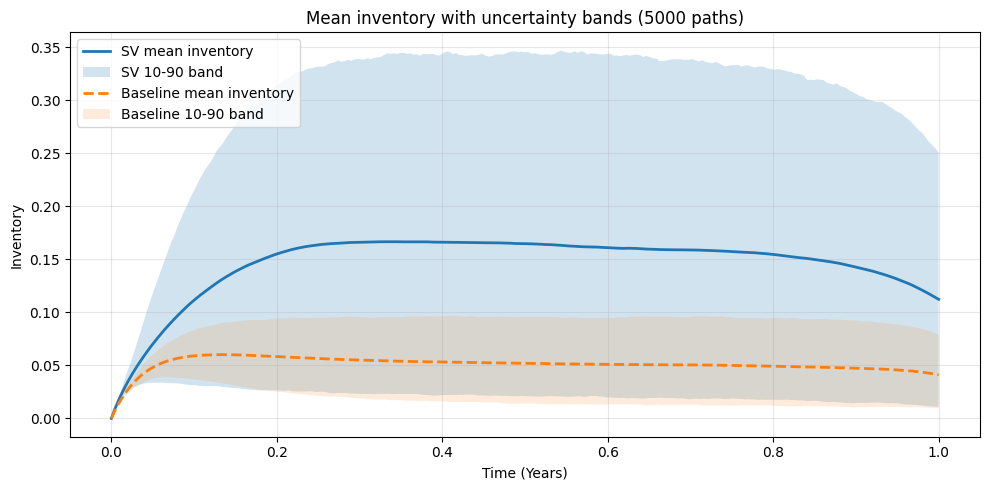

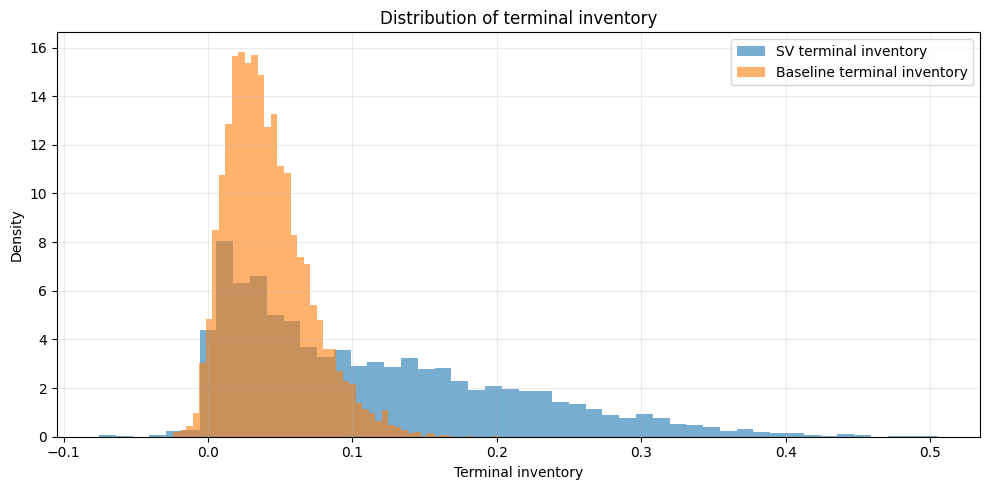

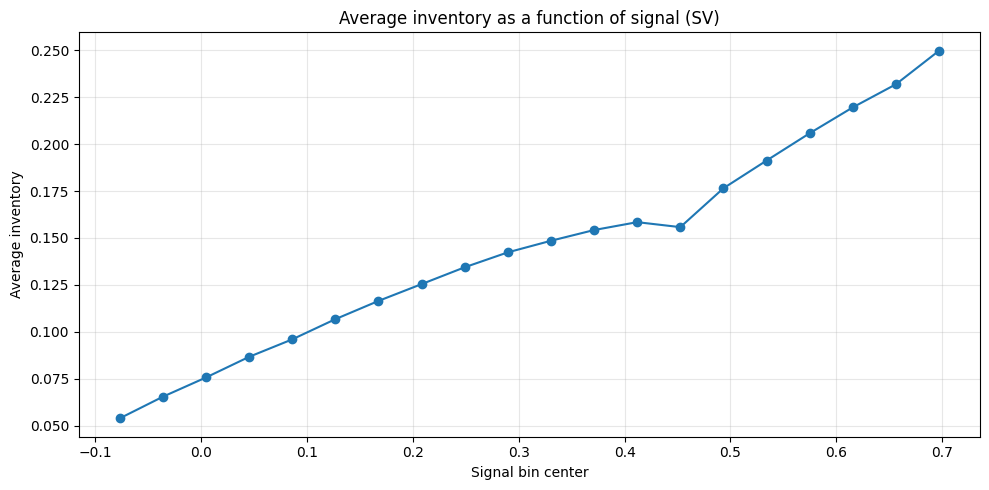

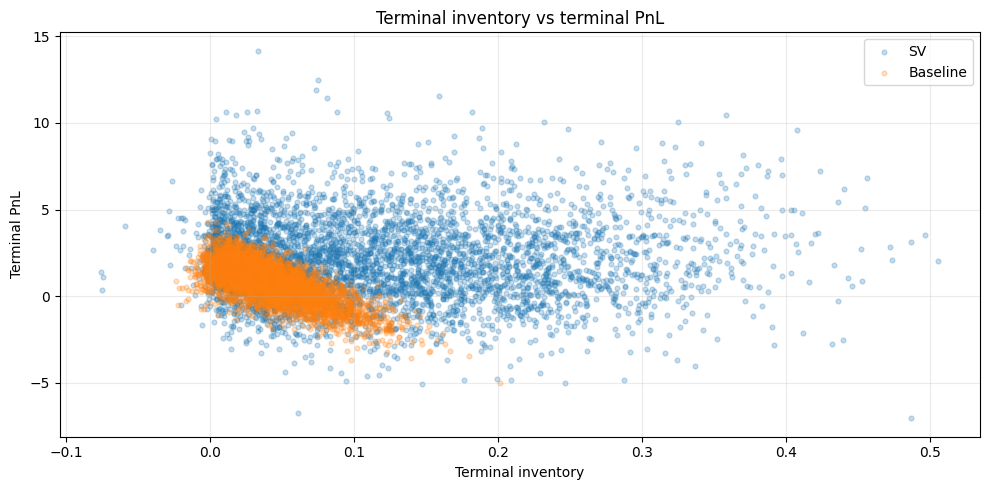


Key diagnostics:
SV mean terminal PnL           : 2.040337
Baseline mean terminal PnL     : 0.851731
Mean pathwise improvement      : 1.188606
95% CI for mean improvement    : [1.138393, 1.238819]
SV mean terminal inventory     : 0.112235
Baseline mean terminal inventory: 0.041036
SV mean abs inventory          : 0.145351
Baseline mean abs inventory    : 0.051005
SV mean turnover               : 1.132559
Baseline mean turnover         : 0.309297
SV mean max drawdown           : 1.872604
Baseline mean max drawdown     : 1.139029


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gamma_test = 0.5
num_paths = 5000
sample_seed = 0
NP, Nx, Ny, Nz = 12, 12, 8, 1
T = 1.0
dt_solver_input = 1.0 / 252.0

print(f"Solving backward PDEs for gamma = {gamma_test} ...")

a_hist_sv, b_hist_sv, c_hist_sv, P_grid, x_grid, y_grid, z_grid, dt_solver, params = run_backward_pde(
    gamma_val=gamma_test,
    is_sv_model=True,
    verbose=True,
    NP=NP, Nx=Nx, Ny=Ny, Nz=Nz,
    T=T,
    dt_solver=dt_solver_input,
)

a_hist_base, b_hist_base, c_hist_base, *_ = run_backward_pde(
    gamma_val=gamma_test,
    is_sv_model=False,
    verbose=False,
    NP=NP, Nx=Nx, Ny=Ny, Nz=Nz,
    T=T,
    dt_solver=dt_solver_input,
)

time_steps = len(a_hist_sv)
time_axis = np.linspace(0.0, (time_steps - 1) * dt_solver, time_steps)


def max_drawdown_from_path(pnl_path):
    pnl_path = np.asarray(pnl_path)
    running_max = np.maximum.accumulate(pnl_path)
    drawdown = running_max - pnl_path
    return float(np.max(drawdown))

def summarize_terminal(x):
    x = np.asarray(x)
    n = len(x)
    mean = np.mean(x)
    std = np.std(x, ddof=1) if n > 1 else 0.0
    se = std / np.sqrt(n) if n > 1 else 0.0
    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se
    return {
        "mean": mean,
        "median": np.median(x),
        "std": std,
        "p05": np.percentile(x, 5),
        "p95": np.percentile(x, 95),
        "prob_positive": np.mean(x > 0.0),
        "ci95_low": ci_low,
        "ci95_high": ci_high,
    }

all_pnl_sv = np.zeros((num_paths, time_steps))
all_pnl_base = np.zeros((num_paths, time_steps))

all_q_sv = np.zeros((num_paths, time_steps))
all_q_base = np.zeros((num_paths, time_steps))

all_x_sv = np.zeros((num_paths, time_steps))
all_x_base = np.zeros((num_paths, time_steps))

all_p_sv = np.zeros((num_paths, time_steps))
all_p_base = np.zeros((num_paths, time_steps))

turnover_sv = np.zeros(num_paths)
turnover_base = np.zeros(num_paths)

mean_abs_q_sv = np.zeros(num_paths)
mean_abs_q_base = np.zeros(num_paths)

max_dd_sv = np.zeros(num_paths)
max_dd_base = np.zeros(num_paths)

for i in range(num_paths):
    Q_sv, X_sv, PnL_sv, P_sv = simulate_forward_path(
        a_hist_sv, b_hist_sv, gamma_test, params,
        P_grid, x_grid, y_grid, z_grid, dt_solver,
        is_sv_model=True, seed=i, df=df,
    )
    Q_base, X_base, PnL_base, P_base = simulate_forward_path(
        a_hist_base, b_hist_base, gamma_test, params,
        P_grid, x_grid, y_grid, z_grid, dt_solver,
        is_sv_model=False, seed=i, df=df,
    )

    all_pnl_sv[i, :] = PnL_sv
    all_pnl_base[i, :] = PnL_base

    all_q_sv[i, :] = Q_sv
    all_q_base[i, :] = Q_base

    all_x_sv[i, :] = X_sv
    all_x_base[i, :] = X_base

    all_p_sv[i, :] = P_sv
    all_p_base[i, :] = P_base

    turnover_sv[i] = np.sum(np.abs(np.diff(Q_sv)))
    turnover_base[i] = np.sum(np.abs(np.diff(Q_base)))

    mean_abs_q_sv[i] = np.mean(np.abs(Q_sv))
    mean_abs_q_base[i] = np.mean(np.abs(Q_base))

    max_dd_sv[i] = max_drawdown_from_path(PnL_sv)
    max_dd_base[i] = max_drawdown_from_path(PnL_base)

terminal_pnl_sv = all_pnl_sv[:, -1]
terminal_pnl_base = all_pnl_base[:, -1]
terminal_diff = terminal_pnl_sv - terminal_pnl_base

terminal_q_sv = all_q_sv[:, -1]
terminal_q_base = all_q_base[:, -1]

summary_rows = []

sv_stats = summarize_terminal(terminal_pnl_sv)
summary_rows.append({
    "strategy": "SV",
    "mean_terminal_pnl": sv_stats["mean"],
    "median_terminal_pnl": sv_stats["median"],
    "std_terminal_pnl": sv_stats["std"],
    "p05_terminal_pnl": sv_stats["p05"],
    "p95_terminal_pnl": sv_stats["p95"],
    "prob_positive_terminal_pnl": sv_stats["prob_positive"],
    "ci95_low_mean_pnl": sv_stats["ci95_low"],
    "ci95_high_mean_pnl": sv_stats["ci95_high"],
    "mean_terminal_inventory": np.mean(terminal_q_sv),
    "mean_abs_inventory": np.mean(mean_abs_q_sv),
    "mean_turnover": np.mean(turnover_sv),
    "mean_max_drawdown": np.mean(max_dd_sv),
})

base_stats = summarize_terminal(terminal_pnl_base)
summary_rows.append({
    "strategy": "Baseline",
    "mean_terminal_pnl": base_stats["mean"],
    "median_terminal_pnl": base_stats["median"],
    "std_terminal_pnl": base_stats["std"],
    "p05_terminal_pnl": base_stats["p05"],
    "p95_terminal_pnl": base_stats["p95"],
    "prob_positive_terminal_pnl": base_stats["prob_positive"],
    "ci95_low_mean_pnl": base_stats["ci95_low"],
    "ci95_high_mean_pnl": base_stats["ci95_high"],
    "mean_terminal_inventory": np.mean(terminal_q_base),
    "mean_abs_inventory": np.mean(mean_abs_q_base),
    "mean_turnover": np.mean(turnover_base),
    "mean_max_drawdown": np.mean(max_dd_base),
})

diff_stats = summarize_terminal(terminal_diff)
summary_rows.append({
    "strategy": "SV - Baseline",
    "mean_terminal_pnl": diff_stats["mean"],
    "median_terminal_pnl": diff_stats["median"],
    "std_terminal_pnl": diff_stats["std"],
    "p05_terminal_pnl": diff_stats["p05"],
    "p95_terminal_pnl": diff_stats["p95"],
    "prob_positive_terminal_pnl": diff_stats["prob_positive"],
    "ci95_low_mean_pnl": diff_stats["ci95_low"],
    "ci95_high_mean_pnl": diff_stats["ci95_high"],
    "mean_terminal_inventory": np.mean(terminal_q_sv - terminal_q_base),
    "mean_abs_inventory": np.mean(mean_abs_q_sv - mean_abs_q_base),
    "mean_turnover": np.mean(turnover_sv - turnover_base),
    "mean_max_drawdown": np.mean(max_dd_sv - max_dd_base),
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))

def mean_and_band(arr, low=10, high=90):
    mean = np.mean(arr, axis=0)
    lo = np.percentile(arr, low, axis=0)
    hi = np.percentile(arr, high, axis=0)
    return mean, lo, hi

mean_pnl_sv, pnl_lo_sv, pnl_hi_sv = mean_and_band(all_pnl_sv, 10, 90)
mean_pnl_base, pnl_lo_base, pnl_hi_base = mean_and_band(all_pnl_base, 10, 90)

mean_q_sv, q_lo_sv, q_hi_sv = mean_and_band(all_q_sv, 10, 90)
mean_q_base, q_lo_base, q_hi_base = mean_and_band(all_q_base, 10, 90)

Q_sv_sample, X_sv_sample, PnL_sv_sample, P_sv_sample = simulate_forward_path(
    a_hist_sv, b_hist_sv, gamma_test, params,
    P_grid, x_grid, y_grid, z_grid, dt_solver,
    is_sv_model=True, seed=sample_seed, df=df,
)

Q_base_sample, X_base_sample, PnL_base_sample, P_base_sample = simulate_forward_path(
    a_hist_base, b_hist_base, gamma_test, params,
    P_grid, x_grid, y_grid, z_grid, dt_solver,
    is_sv_model=False, seed=sample_seed, df=df,
)

# Plot 1: sample path inventory + signal
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(time_axis, Q_sv_sample, linewidth=2, label='Inventory (SV)')
ax1.set_xlabel('Time (Years)')
ax1.set_ylabel('Inventory')
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(time_axis, X_sv_sample, linestyle='--', alpha=0.8, label='Signal')
ax2.set_ylabel('Signal')

plt.title('Sample path: inventory and signal')
fig.tight_layout()
plt.show()

# Plot 2: mean cumulative PnL with 10-90 bands
plt.figure(figsize=(10, 5))
plt.plot(time_axis, mean_pnl_sv, linewidth=2, label='SV Mean PnL')
plt.fill_between(time_axis, pnl_lo_sv, pnl_hi_sv, alpha=0.20, label='SV 10-90 Band')
plt.plot(time_axis, mean_pnl_base, linestyle='--', linewidth=2, label='Baseline Mean PnL')
plt.fill_between(time_axis, pnl_lo_base, pnl_hi_base, alpha=0.15, label='Baseline 10-90 Band')
plt.xlabel('Time (Years)')
plt.ylabel('Cumulative PnL')
plt.title(f'Mean Cumulative PnL with Uncertainty Bands ({num_paths} Paths)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: histogram of terminal PnL
plt.figure(figsize=(10, 5))
plt.hist(terminal_pnl_sv, bins=50, alpha=0.6, density=True, label='SV Terminal PnL')
plt.hist(terminal_pnl_base, bins=50, alpha=0.6, density=True, label='Baseline Terminal PnL')
plt.xlabel('Terminal PnL')
plt.ylabel('Density')
plt.title(f'Distribution of Terminal PnL ({num_paths} Paths)')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 4: histogram of pathwise SV - baseline difference
plt.figure(figsize=(10, 5))
plt.hist(terminal_diff, bins=50, alpha=0.75, density=True)
plt.axvline(np.mean(terminal_diff), linestyle='--', linewidth=2, label=f'Mean diff = {np.mean(terminal_diff):.4f}')
plt.xlabel('Terminal PnL difference (SV - Baseline)')
plt.ylabel('Density')
plt.title('Pathwise terminal PnL difference')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 5: mean inventory with 10-90 bands
plt.figure(figsize=(10, 5))
plt.plot(time_axis, mean_q_sv, linewidth=2, label='SV mean inventory')
plt.fill_between(time_axis, q_lo_sv, q_hi_sv, alpha=0.20, label='SV 10-90 band')
plt.plot(time_axis, mean_q_base, linestyle='--', linewidth=2, label='Baseline mean inventory')
plt.fill_between(time_axis, q_lo_base, q_hi_base, alpha=0.15, label='Baseline 10-90 band')
plt.xlabel('Time (Years)')
plt.ylabel('Inventory')
plt.title(f'Mean inventory with uncertainty bands ({num_paths} paths)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 6: histogram of terminal inventory
plt.figure(figsize=(10, 5))
plt.hist(terminal_q_sv, bins=50, alpha=0.6, density=True, label='SV terminal inventory')
plt.hist(terminal_q_base, bins=50, alpha=0.6, density=True, label='Baseline terminal inventory')
plt.xlabel('Terminal inventory')
plt.ylabel('Density')
plt.title('Distribution of terminal inventory')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 7: inventory as a function of signal
x_vals = all_x_sv[:, :-1].ravel()
q_vals = all_q_sv[:, :-1].ravel()

num_bins = 20
bin_edges = np.linspace(np.percentile(x_vals, 1), np.percentile(x_vals, 99), num_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_idx = np.digitize(x_vals, bin_edges) - 1

q_bin_means = np.full(num_bins, np.nan)
q_bin_counts = np.zeros(num_bins, dtype=int)

for j in range(num_bins):
    mask = bin_idx == j
    q_bin_counts[j] = np.sum(mask)
    if q_bin_counts[j] > 0:
        q_bin_means[j] = np.mean(q_vals[mask])

plt.figure(figsize=(10, 5))
plt.plot(bin_centers, q_bin_means, marker='o')
plt.xlabel('Signal bin center')
plt.ylabel('Average inventory')
plt.title('Average inventory as a function of signal (SV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 8: terminal inventory vs terminal PnL
plt.figure(figsize=(10, 5))
plt.scatter(terminal_q_sv, terminal_pnl_sv, alpha=0.25, s=12, label='SV')
plt.scatter(terminal_q_base, terminal_pnl_base, alpha=0.25, s=12, label='Baseline')
plt.xlabel('Terminal inventory')
plt.ylabel('Terminal PnL')
plt.title('Terminal inventory vs terminal PnL')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("\nKey diagnostics:")
print(f"SV mean terminal PnL           : {np.mean(terminal_pnl_sv):.6f}")
print(f"Baseline mean terminal PnL     : {np.mean(terminal_pnl_base):.6f}")
print(f"Mean pathwise improvement      : {np.mean(terminal_diff):.6f}")
print(f"95% CI for mean improvement    : [{diff_stats['ci95_low']:.6f}, {diff_stats['ci95_high']:.6f}]")
print(f"SV mean terminal inventory     : {np.mean(terminal_q_sv):.6f}")
print(f"Baseline mean terminal inventory: {np.mean(terminal_q_base):.6f}")
print(f"SV mean abs inventory          : {np.mean(mean_abs_q_sv):.6f}")
print(f"Baseline mean abs inventory    : {np.mean(mean_abs_q_base):.6f}")
print(f"SV mean turnover               : {np.mean(turnover_sv):.6f}")
print(f"Baseline mean turnover         : {np.mean(turnover_base):.6f}")
print(f"SV mean max drawdown           : {np.mean(max_dd_sv):.6f}")
print(f"Baseline mean max drawdown     : {np.mean(max_dd_base):.6f}")

,mean,std,skewness,kurtosis,q05,q50,q95,lower_tail_mean_5pct,upper_tail_mean_95pct,upper_minus_lower_tail_mean,prob_positive
SV,2.0403,2.2956,0.4528,3.8901,-1.3843,1.8460,6.0003,-2.3333,7.4833,9.8166,0.8320
Constant Vol,0.8517,1.0831,-0.4612,3.5100,-1.0919,0.9436,2.4645,-1.6638,2.8464,4.5102,0.7986


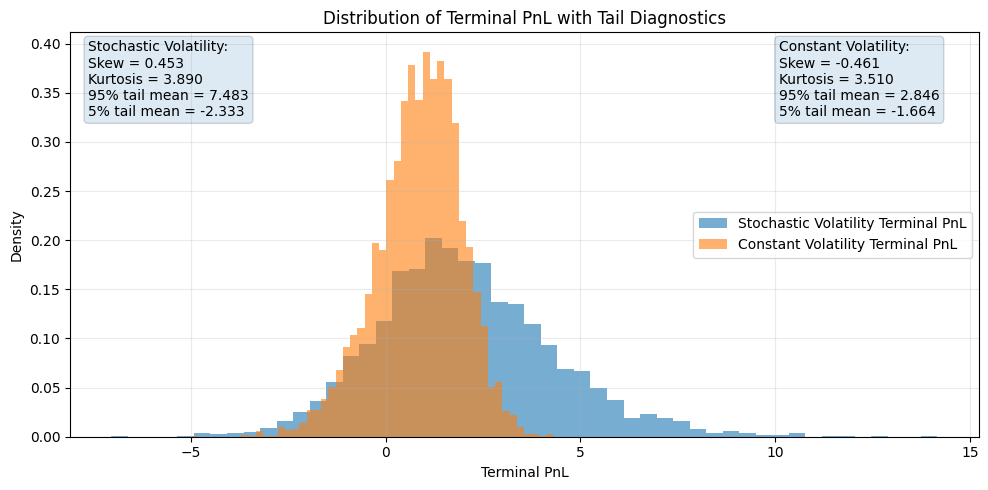

In [50]:
from scipy.stats import skew, kurtosis

def tail_summary(x, alpha=0.05):
    x = np.asarray(x)
    q_low = np.quantile(x, alpha)
    q_high = np.quantile(x, 1 - alpha)

    lower_tail = x[x <= q_low]
    upper_tail = x[x >= q_high]

    return {
        "mean": np.mean(x),
        "std": np.std(x, ddof=1),
        "skewness": skew(x, bias=False),
        "kurtosis": kurtosis(x, fisher=False, bias=False),
        "q05": q_low,
        "q50": np.median(x),
        "q95": q_high,
        "lower_tail_mean_5pct": np.mean(lower_tail),
        "upper_tail_mean_95pct": np.mean(upper_tail),
        "upper_minus_lower_tail_mean": np.mean(upper_tail) - np.mean(lower_tail),
        "prob_positive": np.mean(x > 0),
    }

sv_tail = tail_summary(terminal_pnl_sv, alpha=0.05)
base_tail = tail_summary(terminal_pnl_base, alpha=0.05)

tail_df = pd.DataFrame(
    [sv_tail, base_tail],
    index=["SV", "Constant Vol"]
)

display(tail_df.round(4))

plt.figure(figsize=(10, 5))
plt.hist(terminal_pnl_sv, bins=50, alpha=0.6, density=True, label='Stochastic Volatility Terminal PnL')
plt.hist(terminal_pnl_base, bins=50, alpha=0.6, density=True, label='Constant Volatility Terminal PnL')

text_sv = (
    f"Stochastic Volatility:\n"
    f"Skew = {sv_tail['skewness']:.3f}\n"
    f"Kurtosis = {sv_tail['kurtosis']:.3f}\n"
    f"95% tail mean = {sv_tail['upper_tail_mean_95pct']:.3f}\n"
    f"5% tail mean = {sv_tail['lower_tail_mean_5pct']:.3f}"
)

text_base = (
    f"Constant Volatility:\n"
    f"Skew = {base_tail['skewness']:.3f}\n"
    f"Kurtosis = {base_tail['kurtosis']:.3f}\n"
    f"95% tail mean = {base_tail['upper_tail_mean_95pct']:.3f}\n"
    f"5% tail mean = {base_tail['lower_tail_mean_5pct']:.3f}"
)

plt.text(
    0.02, 0.98, text_sv,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', alpha=0.15)
)

plt.text(
    0.78, 0.98, text_base,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', alpha=0.15)
)

plt.xlabel("Terminal PnL")
plt.ylabel("Density")
plt.title("Distribution of Terminal PnL with Tail Diagnostics")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Running gamma = 0.1 ...
Running gamma = 0.25 ...
Running gamma = 0.5 ...
Running gamma = 1.0 ...
Running gamma = 2.0 ...


,gamma,mean_terminal_pnl_sv,mean_terminal_pnl_baseline,mean_difference,median_difference,std_sv,std_baseline,std_difference,ci95_low_sv,ci95_high_sv,ci95_low_baseline,ci95_high_baseline,ci95_low_diff,ci95_high_diff,prob_sv_beats_baseline
0,0.10,6.0460,3.4180,2.6280,1.9002,8.0534,4.9445,5.7379,5.6931,6.3990,3.2013,3.6347,2.3766,2.8795,0.650
1,0.25,3.2809,1.5805,1.7004,1.1814,3.9584,2.1063,2.9616,3.1074,3.4544,1.4882,1.6728,1.5706,1.8302,0.699
2,0.50,2.0285,0.8572,1.1713,0.8407,2.3386,1.0904,1.8249,1.9260,2.1310,0.8094,0.9050,1.0913,1.2513,0.727
3,1.00,1.2412,0.4561,0.7851,0.5785,1.4006,0.5601,1.1409,1.1798,1.3026,0.4315,0.4806,0.7351,0.8351,0.743
4,2.00,0.7524,0.2389,0.5135,0.3938,0.8535,0.2861,0.7243,0.7150,0.7898,0.2263,0.2514,0.4818,0.5453,0.758


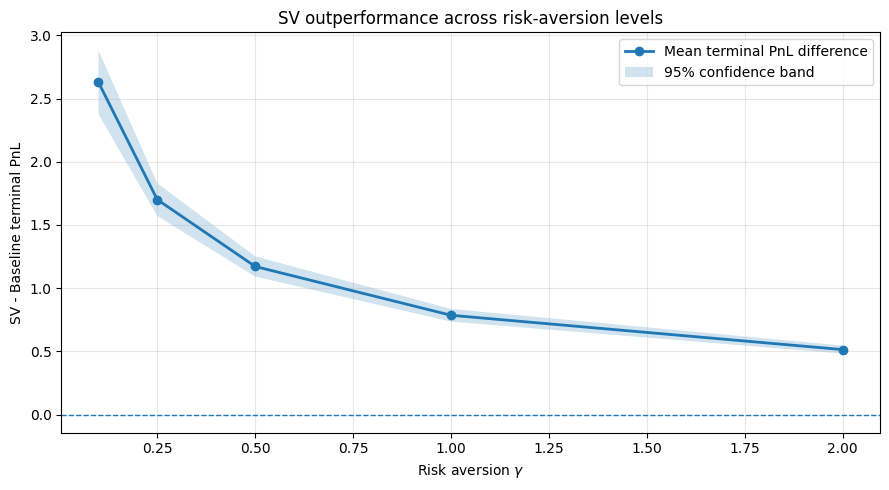

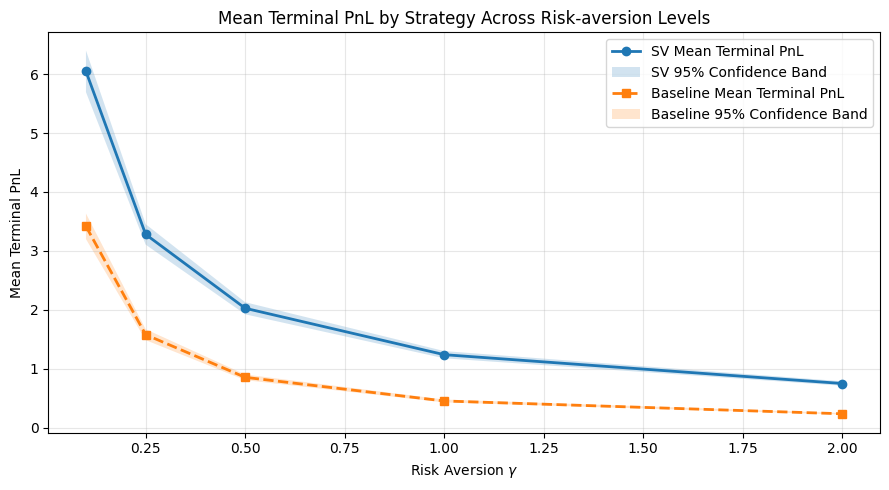

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gamma_grid = [0.1, 0.25, 0.5, 1.0, 2.0]
num_paths_gamma = 2000
NP, Nx, Ny, Nz = 12, 12, 8, 1
T = 1.0
dt_solver_input = 1.0 / 252.0

rows = []

for gamma_val in gamma_grid:
    print(f"Running gamma = {gamma_val} ...")

    a_hist_sv, b_hist_sv, c_hist_sv, P_grid, x_grid, y_grid, z_grid, dt_solver, params = run_backward_pde(
        gamma_val=gamma_val,
        is_sv_model=True,
        verbose=False,
        NP=NP, Nx=Nx, Ny=Ny, Nz=Nz,
        T=T,
        dt_solver=dt_solver_input,
    )

    a_hist_base, b_hist_base, c_hist_base, *_ = run_backward_pde(
        gamma_val=gamma_val,
        is_sv_model=False,
        verbose=False,
        NP=NP, Nx=Nx, Ny=Ny, Nz=Nz,
        T=T,
        dt_solver=dt_solver_input,
    )

    terminal_pnl_sv = np.zeros(num_paths_gamma)
    terminal_pnl_base = np.zeros(num_paths_gamma)

    for i in range(num_paths_gamma):
        Q_sv, X_sv, PnL_sv, P_sv = simulate_forward_path(
            a_hist_sv, b_hist_sv, gamma_val, params,
            P_grid, x_grid, y_grid, z_grid, dt_solver,
            is_sv_model=True, seed=i, df=df
        )

        Q_base, X_base, PnL_base, P_base = simulate_forward_path(
            a_hist_base, b_hist_base, gamma_val, params,
            P_grid, x_grid, y_grid, z_grid, dt_solver,
            is_sv_model=False, seed=i, df=df
        )

        terminal_pnl_sv[i] = PnL_sv[-1]
        terminal_pnl_base[i] = PnL_base[-1]

    diff = terminal_pnl_sv - terminal_pnl_base

    mean_sv = np.mean(terminal_pnl_sv)
    mean_base = np.mean(terminal_pnl_base)
    mean_diff = np.mean(diff)
    median_diff = np.median(diff)

    std_sv = np.std(terminal_pnl_sv, ddof=1)
    std_base = np.std(terminal_pnl_base, ddof=1)
    std_diff = np.std(diff, ddof=1)

    se_sv = std_sv / np.sqrt(num_paths_gamma)
    se_base = std_base / np.sqrt(num_paths_gamma)
    se_diff = std_diff / np.sqrt(num_paths_gamma)

    ci_low_sv = mean_sv - 1.96 * se_sv
    ci_high_sv = mean_sv + 1.96 * se_sv

    ci_low_base = mean_base - 1.96 * se_base
    ci_high_base = mean_base + 1.96 * se_base

    ci_low_diff = mean_diff - 1.96 * se_diff
    ci_high_diff = mean_diff + 1.96 * se_diff

    prob_outperform = np.mean(diff > 0)

    rows.append({
        "gamma": gamma_val,
        "mean_terminal_pnl_sv": mean_sv,
        "mean_terminal_pnl_baseline": mean_base,
        "mean_difference": mean_diff,
        "median_difference": median_diff,
        "std_sv": std_sv,
        "std_baseline": std_base,
        "std_difference": std_diff,
        "ci95_low_sv": ci_low_sv,
        "ci95_high_sv": ci_high_sv,
        "ci95_low_baseline": ci_low_base,
        "ci95_high_baseline": ci_high_base,
        "ci95_low_diff": ci_low_diff,
        "ci95_high_diff": ci_high_diff,
        "prob_sv_beats_baseline": prob_outperform,
    })

gamma_df = pd.DataFrame(rows)
display(gamma_df.round(4))

# Plot 1: mean outperformance with 95% CI
plt.figure(figsize=(9, 5))
plt.plot(
    gamma_df["gamma"],
    gamma_df["mean_difference"],
    marker="o",
    linewidth=2,
    label="Mean terminal PnL difference"
)
plt.fill_between(
    gamma_df["gamma"],
    gamma_df["ci95_low_diff"],
    gamma_df["ci95_high_diff"],
    alpha=0.2,
    label="95% confidence band"
)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel(r"Risk aversion $\gamma$")
plt.ylabel("SV - Baseline terminal PnL")
plt.title("SV outperformance across risk-aversion levels")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: both strategies with 95% confidence bands
plt.figure(figsize=(9, 5))

plt.plot(
    gamma_df["gamma"],
    gamma_df["mean_terminal_pnl_sv"],
    marker="o",
    linewidth=2,
    label="SV Mean Terminal PnL"
)
plt.fill_between(
    gamma_df["gamma"],
    gamma_df["ci95_low_sv"],
    gamma_df["ci95_high_sv"],
    alpha=0.2,
    label="SV 95% Confidence Band"
)

plt.plot(
    gamma_df["gamma"],
    gamma_df["mean_terminal_pnl_baseline"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Baseline Mean Terminal PnL"
)
plt.fill_between(
    gamma_df["gamma"],
    gamma_df["ci95_low_baseline"],
    gamma_df["ci95_high_baseline"],
    alpha=0.2,
    label="Baseline 95% Confidence Band"
)

plt.xlabel(r"Risk Aversion $\gamma$")
plt.ylabel("Mean Terminal PnL")
plt.title("Mean Terminal PnL by Strategy Across Risk-aversion Levels")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

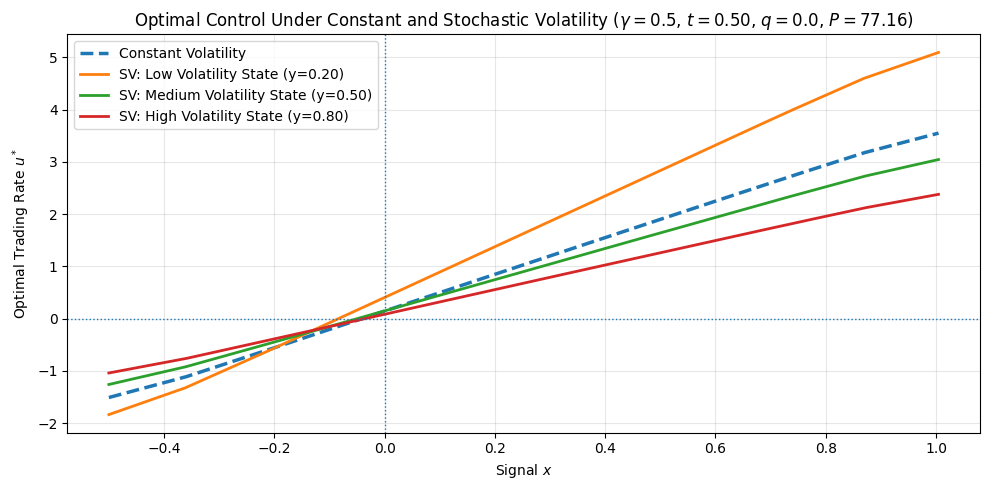

P_fixed = 77.1563
y_low, y_mid, y_high = 0.2000, 0.5000, 0.8000


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

gamma_plot = 0.5
NP, Nx, Ny, Nz = 12, 12, 8, 1
T = 1.0
dt_solver_input = 1.0 / 252.0

time_index = len(a_hist_sv)//2
q_fixed = 0.0
P_fixed_mode = "median" # "median" or "initial"

a_hist_sv, b_hist_sv, c_hist_sv, P_grid, x_grid, y_grid, z_grid, dt_solver, params = run_backward_pde(
    gamma_val=gamma_plot,
    is_sv_model=True,
    verbose=False,
    NP=NP, Nx=Nx, Ny=Ny, Nz=Nz,
    T=T,
    dt_solver=dt_solver_input,
)

a_hist_base, b_hist_base, c_hist_base, *_ = run_backward_pde(
    gamma_val=gamma_plot,
    is_sv_model=False,
    verbose=False,
    NP=NP, Nx=Nx, Ny=Ny, Nz=Nz,
    T=T,
    dt_solver=dt_solver_input,
)

K = params["K"]

if P_fixed_mode == "initial" and "df" in globals():
    try:
        P_fixed = float(df["Close"].dropna().iloc[0])
    except:
        P_fixed = float(np.median(P_grid))
else:
    P_fixed = float(np.median(P_grid))

P_fixed = min(max(P_fixed, float(np.min(P_grid))), float(np.max(P_grid)))

def make_interp(field_3d):
    return RegularGridInterpolator(
        (P_grid, x_grid, y_grid),
        field_3d,
        bounds_error=False,
        fill_value=None
    )

a_interp_sv = make_interp(a_hist_sv[time_index])
b_interp_sv = make_interp(b_hist_sv[time_index])

a_interp_base = make_interp(a_hist_base[time_index])
b_interp_base = make_interp(b_hist_base[time_index])

x_vals = np.linspace(float(np.min(x_grid)), float(np.max(x_grid)), 1000)

y_low  = float(np.percentile(y_grid, 20))
y_mid  = float(np.percentile(y_grid, 50))
y_high = float(np.percentile(y_grid, 80))

y_base = y_mid

u_base = np.zeros_like(x_vals)
u_sv_low = np.zeros_like(x_vals)
u_sv_mid = np.zeros_like(x_vals)
u_sv_high = np.zeros_like(x_vals)

for i, x_val in enumerate(x_vals):
    pt_base = np.array([[P_fixed, x_val, y_base]])
    pt_low  = np.array([[P_fixed, x_val, y_low]])
    pt_mid  = np.array([[P_fixed, x_val, y_mid]])
    pt_high = np.array([[P_fixed, x_val, y_high]])

    a_b = a_interp_base(pt_base).item()
    b_b = b_interp_base(pt_base).item()

    a_l = a_interp_sv(pt_low).item()
    b_l = b_interp_sv(pt_low).item()

    a_m = a_interp_sv(pt_mid).item()
    b_m = b_interp_sv(pt_mid).item()

    a_h = a_interp_sv(pt_high).item()
    b_h = b_interp_sv(pt_high).item()

    u_base[i]    = (2.0 * a_b * q_fixed + b_b) / K
    u_sv_low[i]  = (2.0 * a_l * q_fixed + b_l) / K
    u_sv_mid[i]  = (2.0 * a_m * q_fixed + b_m) / K
    u_sv_high[i] = (2.0 * a_h * q_fixed + b_h) / K

plt.figure(figsize=(10, 5))
plt.plot(x_vals, u_base, linestyle="--", linewidth=2.5, label=f"Constant Volatility")
plt.plot(x_vals, u_sv_low, linewidth=2, label=f"SV: Low Volatility State (y={y_low:.2f})")
plt.plot(x_vals, u_sv_mid, linewidth=2, label=f"SV: Medium Volatility State (y={y_mid:.2f})")
plt.plot(x_vals, u_sv_high, linewidth=2, label=f"SV: High Volatility State (y={y_high:.2f})")

plt.axhline(0.0, linestyle=":", linewidth=1)
plt.axvline(0.0, linestyle=":", linewidth=1)

plt.xlabel("Signal $x$")
plt.ylabel("Optimal Trading Rate $u^*$")
plt.title(
    rf"Optimal Control Under Constant and Stochastic Volatility "
    rf"($\gamma={gamma_plot}$, $t={(time_index * dt_solver_input):.2f}$, $q={q_fixed}$, $P={P_fixed:.2f}$)"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"P_fixed = {P_fixed:.4f}")
print(f"y_low, y_mid, y_high = {y_low:.4f}, {y_mid:.4f}, {y_high:.4f}")